# Libraries

In [3]:
import os
import pandas as pd
import numpy
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,MinMaxScaler


# Importing Data

In [4]:
import kagglehub
# Download latest version
path = kagglehub.dataset_download("abbas829/telco-customer-churn-dataset")
print("Path to dataset files:", path)


100%|██████████| 172k/172k [00:00<00:00, 336kB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/abbas829/telco-customer-churn-dataset/versions/1


In [5]:
# Find the CSV file inside the downloaded folder
dataset_files = os.listdir(path)
print("Files downloaded:", dataset_files)

# Get the exact name of the CSV file
csv_filename = [file for file in dataset_files if file.endswith('.csv')][0]

# Create the full path to the CSV file
full_csv_path = os.path.join(path, csv_filename)

# Load the data into a pandas DataFrame
df = pd.read_csv(full_csv_path)

df.head()

Files downloaded: ['Telco-Customer-Churn.csv']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# Data Validation

**Accuracy**

In [ ]:
# Categorical Invalid Check
print("Categorical Invalid Accuracy Check: ")
print("Gender invalid:", df[~df["gender"].isin(["Male", "Female"])].shape[0])

print("SeniorCitizen invalid:", df[~df["SeniorCitizen"].isin([0, 1])].shape[0])

print("Partner invalid:", df[~df["Partner"].isin(["Yes", "No"])].shape[0])

print("Dependents invalid:", df[~df["Dependents"].isin(["Yes", "No"])].shape[0])

print("PhoneService invalid:", df[~df["PhoneService"].isin(["Yes", "No"])].shape[0])

print("MultipleLines invalid:", df[~df["MultipleLines"].isin(["Yes", "No", "No phone service"])].shape[0])

print("InternetService invalid:", df[~df["InternetService"].isin(["DSL", "Fiber optic", "No"])].shape[0])

print("Contract invalid:", df[~df["Contract"].isin(["Month-to-month", "One year", "Two year"])].shape[0])

print("PaperlessBilling invalid:", df[~df["PaperlessBilling"].isin(["Yes", "No"])].shape[0])

print("Churn invalid:", df[~df["Churn"].isin(["Yes", "No"])].shape[0])

print("-"*60)
# Service-related accuracy checks
print("\nService-related accuracy checks: ")
print("OnlineSecurity invalid:",
      df[~df["OnlineSecurity"].isin(["Yes", "No", "No internet service"])].shape[0])

print("OnlineBackup invalid:",
      df[~df["OnlineBackup"].isin(["Yes", "No", "No internet service"])].shape[0])

print("DeviceProtection invalid:",
      df[~df["DeviceProtection"].isin(["Yes", "No", "No internet service"])].shape[0])

print("TechSupport invalid:",
      df[~df["TechSupport"].isin(["Yes", "No", "No internet service"])].shape[0])

print("StreamingTV invalid:",
      df[~df["StreamingTV"].isin(["Yes", "No", "No internet service"])].shape[0])

print("StreamingMovies invalid:",
      df[~df["StreamingMovies"].isin(["Yes", "No", "No internet service"])].shape[0])

print("-"*60)

print("\nNumeric accuracy checks: ")

print("Negative tenure:", (df["tenure"] < 0).sum())

print("Negative MonthlyCharges:", (df["MonthlyCharges"] < 0).sum())

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("Missing TotalCharges:",df["TotalCharges"].isna().sum())

print("Negative TotalCharges:", (df["TotalCharges"] < 0).sum())

print("-"*60)

print("\ncustomerID format issues checks: ")
print("Invalid customerID format:",
      df[~df["customerID"].astype(str).str.match("^[0-9A-Za-z-]+$")].shape[0])

Categorical Invalid Accuracy Check: 
Gender invalid: 0
SeniorCitizen invalid: 0
Partner invalid: 0
Dependents invalid: 0
PhoneService invalid: 0
MultipleLines invalid: 0
InternetService invalid: 0
Contract invalid: 0
PaperlessBilling invalid: 0
Churn invalid: 0
------------------------------------------------------------

Service-related accuracy checks: 
OnlineSecurity invalid: 0
OnlineBackup invalid: 0
DeviceProtection invalid: 0
TechSupport invalid: 0
StreamingTV invalid: 0
StreamingMovies invalid: 0
------------------------------------------------------------

Numeric accuracy checks: 
Negative tenure: 0
Negative MonthlyCharges: 0
Missing TotalCharges: 11
Negative TotalCharges: 0
------------------------------------------------------------

customerID format issues checks: 
Invalid customerID format: 0


In [ ]:
# one example for the missing totalcharges
# Since the tenure is 0, The customer has just joined and has not completed any billing cycle yet.
print(df[df["TotalCharges"].isna()].head(1).T)

                                        488
customerID                       4472-LVYGI
gender                               Female
SeniorCitizen                             0
Partner                                 Yes
Dependents                              Yes
tenure                                    0
PhoneService                             No
MultipleLines              No phone service
InternetService                         DSL
OnlineSecurity                          Yes
OnlineBackup                             No
DeviceProtection                        Yes
TechSupport                             Yes
StreamingTV                             Yes
StreamingMovies                          No
Contract                           Two year
PaperlessBilling                        Yes
PaymentMethod     Bank transfer (automatic)
MonthlyCharges                        52.55
TotalCharges                            NaN
Churn                                    No


In [ ]:
missing_df = df[df["TotalCharges"].isna()]
print("Missing TotalCharges count:", len(missing_df))
print("All are new customers (tenure=0):", (missing_df["tenure"] == 0).all())
# They correspond to new customers who haven’t been billed yet. There is no data corruption here.

Missing TotalCharges count: 11
All are new customers (tenure=0): True


**Consistancy**

In [ ]:
'''
No inconsistencies were found between InternetService and related internet-dependent features (OnlineSecurity, StreamingTV, etc.).
All customers with No internet service correctly have No internet service in all associated features, indicating strong internal consistency.
'''
df[(df["InternetService"] == "No") &
    (
        (df["OnlineSecurity"] != "No internet service") |
        (df["OnlineBackup"] != "No internet service") |
        (df["DeviceProtection"] != "No internet service") |
        (df["TechSupport"] != "No internet service") |
        (df["StreamingTV"] != "No internet service") |
        (df["StreamingMovies"] != "No internet service")
    )
].shape[0]


0

In [ ]:
'''
No inconsistencies were found between PhoneService and MultipleLines.
All customers without phone service are correctly labeled as “No phone service” in the MultipleLines field, confirming consistent encoding across related variables.
'''
df[
    (df["PhoneService"] == "No") &
    (df["MultipleLines"] != "No phone service")
].shape[0]

0

In [ ]:
df[
    (df["InternetService"] != "No") &
    (
        (df["OnlineSecurity"] == "No internet service") |
        (df["OnlineBackup"] == "No internet service")
    )
].shape[0]

0

In [ ]:
df[
    (df["tenure"] > 0) &
    (df["TotalCharges"].isna())
].shape[0]

0

**Completeness**

In [ ]:
'''
Completeness was evaluated by analyzing missing values across all attributes.
The dataset was found to be with only 11 missing values in TotalCharges.
These missing values were associated with customers having zero tenure, indicating newly registered users who have not yet been billed.
'''
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df[df["TotalCharges"].isna()][["tenure", "MonthlyCharges", "Contract", "Churn"]]


,tenure,MonthlyCharges,Contract,Churn
488,0,52.55,Two year,No
753,0,20.25,Two year,No
936,0,80.85,Two year,No
1082,0,25.75,Two year,No
1340,0,56.05,Two year,No
3331,0,19.85,Two year,No
3826,0,25.35,Two year,No
4380,0,20.00,Two year,No
5218,0,19.70,One year,No
6670,0,73.35,Two year,No


In [ ]:
print(((df.isnull().sum() / len(df)) * 100)[df.isnull().sum() > 0])

TotalCharges    0.156183
dtype: float64


In [ ]:
#Completeness risk check (critical fields)
critical_cols = ["customerID", "gender", "tenure", "MonthlyCharges", "Churn"]
df[critical_cols].isnull().sum()

,0
customerID,0
gender,0
tenure,0
MonthlyCharges,0
Churn,0


**Duplicates**

In [ ]:
# No duplicate records were found at the row level, and customerID values were unique across the dataset.
print(df.duplicated().sum())

0


In [ ]:
print(df["customerID"].duplicated().sum())

0


**Outliers Detection**

In [11]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

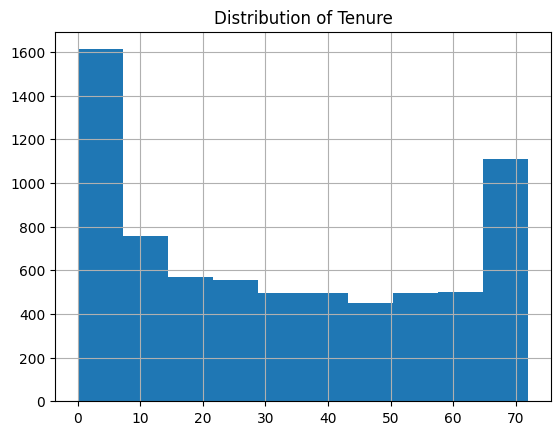

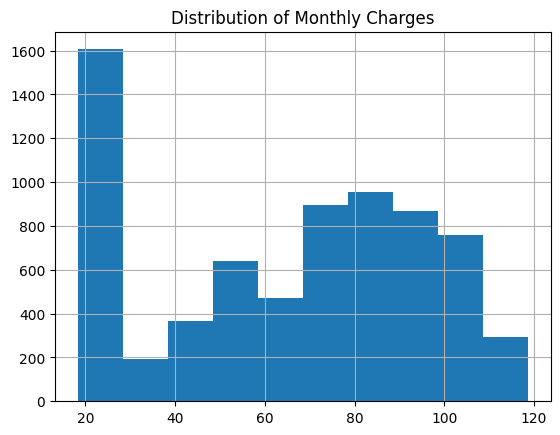

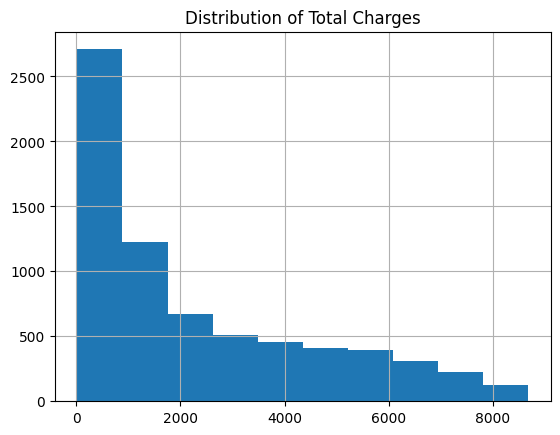

In [ ]:
'''
Z-score NOT suitable
Because:Data is NOT normal and clearly skewed / multi-modal
IQR method can be suitable
'''
df["tenure"].hist()
plt.title("Distribution of Tenure")
plt.show()
df["MonthlyCharges"].hist()
plt.title("Distribution of Monthly Charges")
plt.show()
df["TotalCharges"].hist()
plt.title("Distribution of Total Charges")
plt.show()


In [ ]:
Q1 = df['TotalCharges'].quantile(0.25)
Q3 = df['TotalCharges'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Find the outliers:
outliers = df[(df['TotalCharges'] < lower_bound) | (df['TotalCharges'] > upper_bound)]
print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"lower_bound:{lower_bound}")
print(f"upper_bound:{upper_bound}")
print(f"Outliers found: {len(outliers)}")

Q1: 401.45, Q3: 3794.7375, IQR: 3393.2875000000004
lower_bound:-4688.481250000001
upper_bound:8884.66875
Outliers found: 0


**Distribution Profile**

In [15]:
print("\n--- DISTRIBUTION PROFILE ---")

print("\nStatistical Summary:")
print(df[["tenure", "MonthlyCharges", "TotalCharges"]].describe())

print("\nSkewness:")
print(df[["tenure", "MonthlyCharges", "TotalCharges"]].skew())

print("\nKurtosis:")
print(df[["tenure", "MonthlyCharges", "TotalCharges"]].kurtosis())
'''
tenure is relatively well distributed with slight right skewness, indicating a mix of new and long-term customers.
MonthlyCharges shows mild left skewness and reflects different pricing tiers.

TotalCharges exhibits strong right skewness, with a significant difference between mean and median,
indicating that most customers have low total charges while a small number accumulate very high charges.

Kurtosis values suggest relatively flat distributions without extreme peaks,
although TotalCharges shows a long tail, indicating potential outliers.
'''


--- DISTRIBUTION PROFILE ---

Statistical Summary:
            tenure  MonthlyCharges  TotalCharges
count  7043.000000     7043.000000   7032.000000
mean     32.371149       64.761692   2283.300441
std      24.559481       30.090047   2266.771362
min       0.000000       18.250000     18.800000
25%       9.000000       35.500000    401.450000
50%      29.000000       70.350000   1397.475000
75%      55.000000       89.850000   3794.737500
max      72.000000      118.750000   8684.800000

Skewness:
tenure            0.239540
MonthlyCharges   -0.220524
TotalCharges      0.961642
dtype: float64

Kurtosis:
tenure           -1.387372
MonthlyCharges   -1.257260
TotalCharges     -0.231799
dtype: float64


**Relationships Profile**

In [18]:
print("Pearson Correlation:\n")
print(df[["tenure", "MonthlyCharges", "TotalCharges"]].corr(method="pearson"))

Pearson Correlation:

                 tenure  MonthlyCharges  TotalCharges
tenure          1.00000        0.247900      0.825880
MonthlyCharges  0.24790        1.000000      0.651065
TotalCharges    0.82588        0.651065      1.000000


In [19]:
print("Spearman Correlation:\n")
print(df[["tenure", "MonthlyCharges", "TotalCharges"]].corr(method="spearman"))

Spearman Correlation:

                  tenure  MonthlyCharges  TotalCharges
tenure          1.000000        0.276417      0.889177
MonthlyCharges  0.276417        1.000000      0.638032
TotalCharges    0.889177        0.638032      1.000000


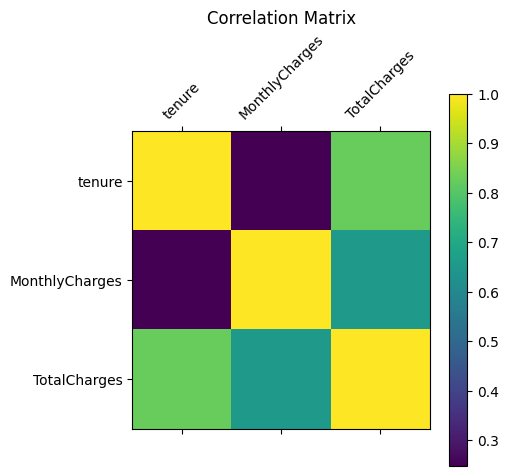

In [20]:
plt.matshow(df[["tenure", "MonthlyCharges", "TotalCharges"]].corr())
plt.colorbar()
plt.xticks(range(3), ["tenure", "MonthlyCharges", "TotalCharges"], rotation=45)
plt.yticks(range(3), ["tenure", "MonthlyCharges", "TotalCharges"])
plt.title("Correlation Matrix")
plt.show()

'''
A strong positive correlation was observed between tenure and TotalCharges, which is expected as total charges accumulate over time.
MonthlyCharges showed moderate correlation with TotalCharges, while tenure and MonthlyCharges exhibited weak correlation.
These findings indicate that some variables are strongly related
'''

# Data Cleaning  

# Feature Engineering

# EDA

# Modelling

# Evaluation

# Testing